In [22]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.signal import butter, sosfiltfilt
import scipy

if __package__ in {None, ""}:
    sys.path.insert(0, str(Path("../").resolve()))

from backend.mag_to_travel_model_core import MagToTravelChunk, MagToTravelModelCore
#from backend.rear_mag_model import RearMagModel

In [23]:
#log_filename = "log146_reartest_sag"
log_filename = "log169_rear_1"

In [24]:
out_dir = f"../backend/run_artifacts/{log_filename}/cache/"
ws_file = out_dir + "/all.npz"
ws = np.load(ws_file)
print([str(key) for key in ws.keys()])
accel_idx = "2"
a = ws[f"accel/lpf/lis{accel_idx}__x"]
a1 = ws[f"accel/lpf/lis1__x"]
b_raw = ws["mag/lpf__x"]
b2_raw = ws["mag_lis/lpf__x"]
b_diff = ws["mag_diff/lpf__x"]
#b_proj = ws["mag/proj/lpf__x"][:, 0]
gyro = ws[f"gyro/lpf/gyro{accel_idx}__x"]
t = ws[f"accel/lpf/lis{accel_idx}__t"]
travel = ws["travel__x"][:, 0]

v_gt = np.gradient(travel, t, edge_order = 2)
a_gt = np.gradient(v_gt, t, edge_order = 2) / 1000.0

['__log_config_hash', 'accel/lis1__t', 'accel/lis1__x', 'gyro/gyro1__t', 'gyro/gyro1__x', 'accel/lis2__t', 'accel/lis2__x', 'gyro/gyro2__t', 'gyro/gyro2__x', 'mag__t', 'mag__x', 'mag_lis__t', 'mag_lis__x', 'angle__t', 'angle__x', 'angle/bad_mask__t', 'angle/bad_mask__x', 'gyro/lpf/gyro1__t', 'gyro/lpf/gyro1__x', 'gyro/lpf/gyro2__t', 'gyro/lpf/gyro2__x', 'accel/lpf/lis1__t', 'accel/lpf/lis1__x', 'accel/lpf/lis2__t', 'accel/lpf/lis2__x', 'lis1_chunks_filt', 'lis2_chunks_filt', 'rotation_matrix', 'accel/lis2_in_lis1__t', 'accel/lis2_in_lis1__x', 'accel/relative__t', 'accel/relative__x', 'accel/lpf/relative__t', 'accel/lpf/relative__x', 'accel_trav_vec', 'mags_vs_means', 'accel/lpf/proj__t', 'accel/lpf/proj__x', 'accel/lphp/proj__t', 'accel/lphp/proj__x', 'angle/lpf__t', 'angle/lpf__x', 'travel__t', 'travel__x', 'boring_mask', 'mag/lpf__t', 'mag/lpf__x', 'mag_lis/lpf__t', 'mag_lis/lpf__x', 'mag_diff__t', 'mag_diff__x', 'mag_diff/lpf__t', 'mag_diff/lpf__x', 'mag/angle__t', 'mag/angle__x', '

In [25]:
# Get mag norm and polar coords
def get_polar(vec):
    mag =  np.linalg.norm(vec, axis=1)
    normed = (vec.T / mag).T
    theta = np.degrees(np.atan2(normed[:, 1], normed[:, 0]))
    phi = np.degrees(np.arcsin(normed[:, 2]))
    return mag, theta, phi

b1_mag, b1_theta, b1_phi = get_polar(b_raw)
b2_mag, b2_theta, b2_phi = get_polar(b2_raw)

b_corr = b_diff
b_corr_mag = np.linalg.norm(b_corr, axis=1)

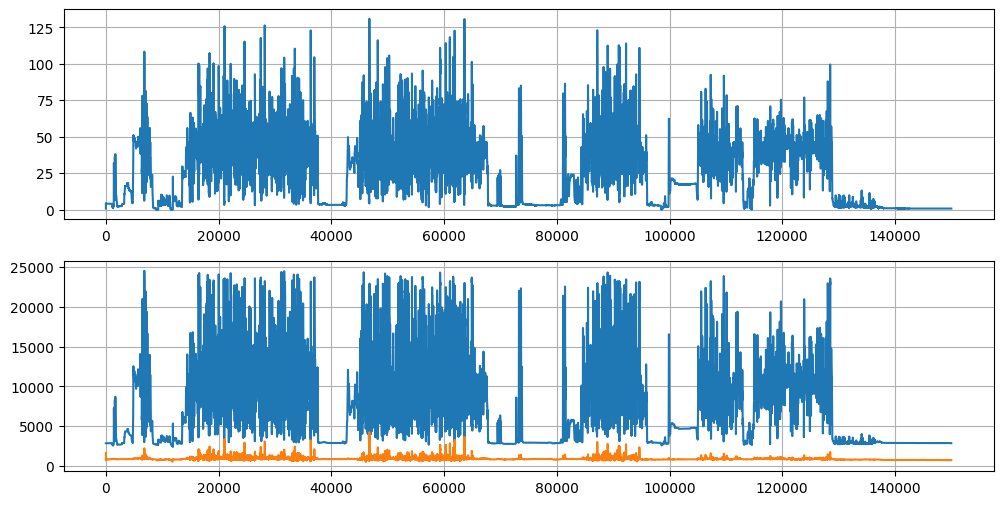

In [26]:
# Plot full travel, mag norm
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(travel)
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(b1_mag)
plt.plot(b2_mag)
plt.grid()

In [27]:
roi = slice(0, -1)
#roi = slice(560*1000, 690*1000)

B1: 0.9814056578929391
B2: 0.8166798350642005
b_corr_mag: 0.9971869916937727


NameError: name 'b_proj' is not defined

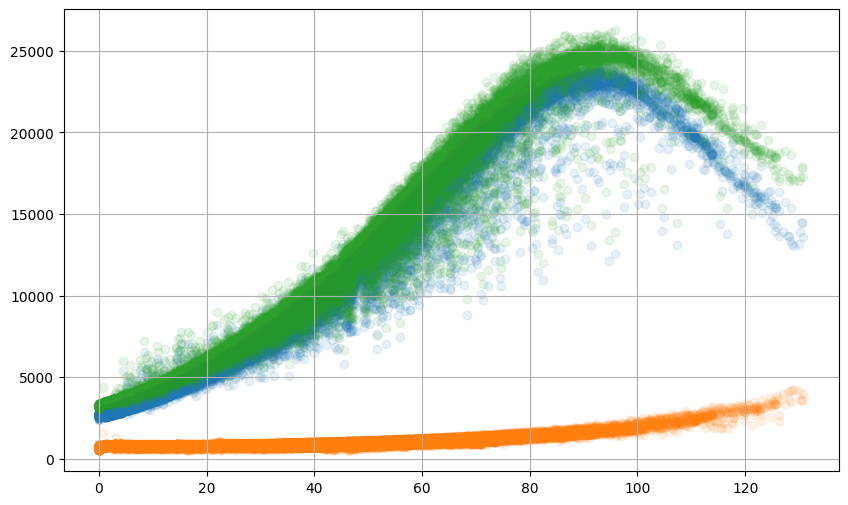

In [28]:
# Plot travel vs mag norm
plt.figure(figsize=(10, 6))
plt.scatter(travel[roi], b1_mag[roi], alpha=0.1)
plt.scatter(travel[roi], b2_mag[roi], alpha=0.1)
plt.scatter(travel[roi], b_corr_mag[roi], alpha=0.1)
# plt.scatter(travel[roi], b_proj[roi], alpha=0.1)
#plt.ylim(10000, 13000)
plt.grid()
spearman = scipy.stats.spearmanr(travel, b1_mag)
print("B1:", spearman.correlation)
spearman = scipy.stats.spearmanr(travel, b2_mag)
print("B2:", spearman.correlation)
spearman = scipy.stats.spearmanr(travel, b_corr_mag)
print("b_corr_mag:", spearman.correlation)
spearman = scipy.stats.spearmanr(travel, b_proj)
print("b_proj:", spearman.correlation)

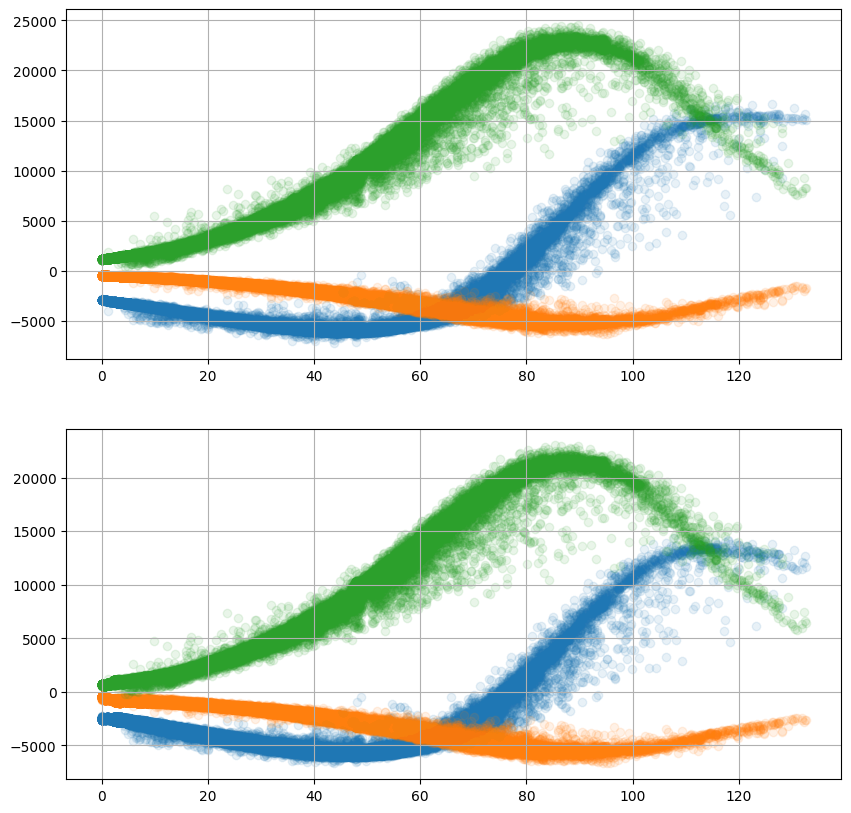

In [ ]:
# Plot travel vs mag axes
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
plt.scatter(travel[roi], b_diff[roi, 0], alpha=0.1)
plt.scatter(travel[roi], b_diff[roi, 1], alpha=0.1)
plt.scatter(travel[roi], b_diff[roi, 2], alpha=0.1)
plt.grid()
plt.subplot(2, 1, 2)
plt.scatter(travel[roi], b_raw[roi, 0], alpha=0.1)
plt.scatter(travel[roi], b_raw[roi, 1], alpha=0.1)
plt.scatter(travel[roi], b_raw[roi, 2], alpha=0.1)
plt.grid()

B diff angle to travel spearman: 0.9980910150186192
B1 angle to travel spearman: 0.9934197690226025


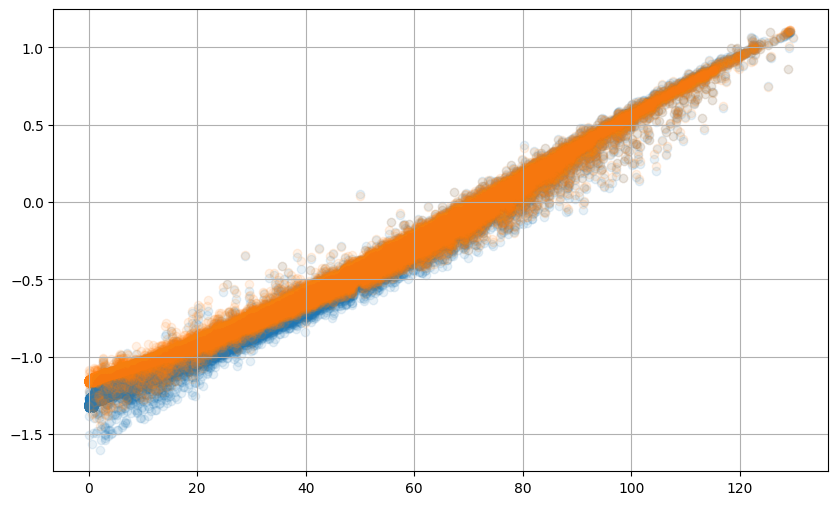

In [ ]:
# Plot travel vs mag angles
def get_b_angle(b):
    norm =  np.linalg.norm(b, axis=1)
    b_diff_normed = (b.T / norm).T
    b_angle = np.atan2(b_diff_normed[:, 0], b_diff_normed[:, 2])
    return b_angle
b_diff_angle = get_b_angle(b_diff)
b1_angle = get_b_angle(b_raw)
plt.figure(figsize=(10, 6))
plt.scatter(travel, b1_angle, alpha=0.1)
plt.scatter(travel, b_diff_angle, alpha=0.1)
plt.grid()
spearman = scipy.stats.spearmanr(travel, b_diff_angle)
print("B diff angle to travel spearman:", spearman.correlation)
spearman = scipy.stats.spearmanr(travel, b1_angle)
print("B1 angle to travel spearman:", spearman.correlation)

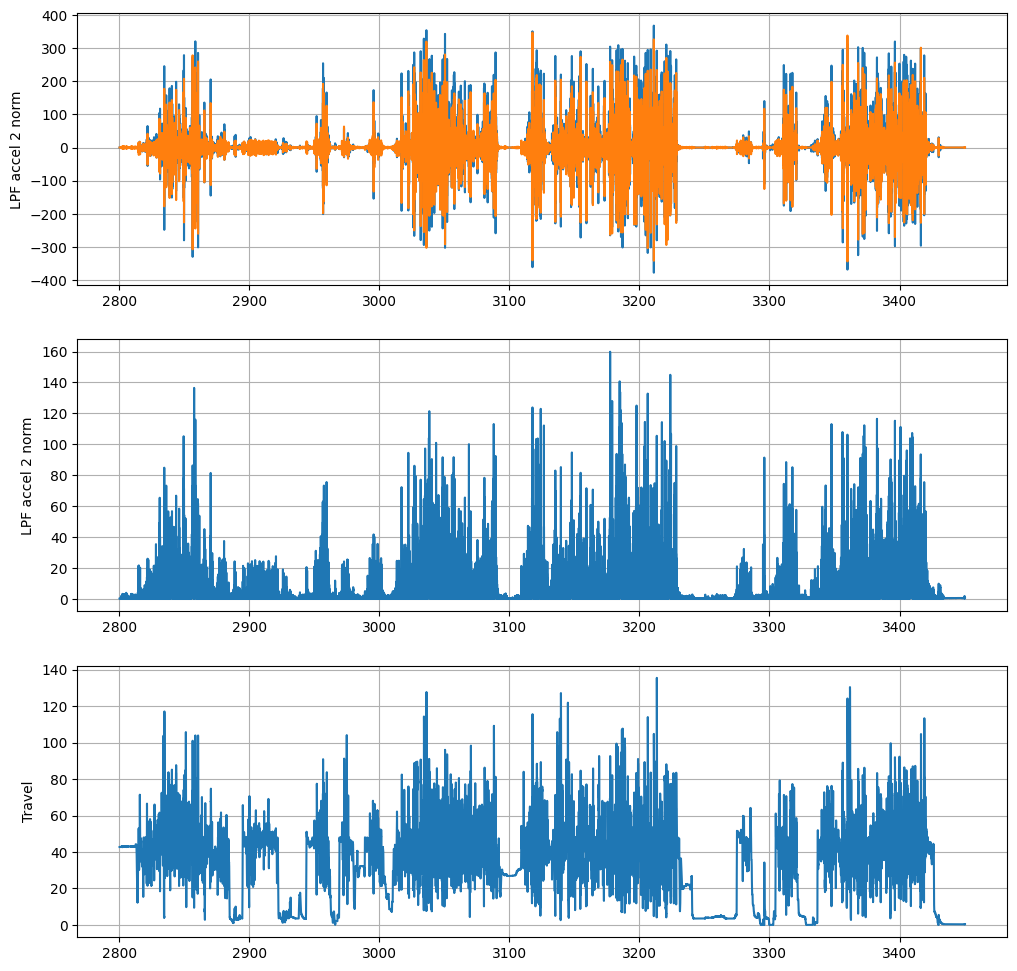

In [ ]:
# Plot accelerometer, travel
a_proj = ws[f"accel/lpf/proj__x"][:, 0]

plt.figure(figsize=(12, 12))
plt.subplot(3, 1, 1)
plt.ylabel(f"LPF accel {accel_idx} norm")
plt.plot(t[roi], a_proj[roi])
plt.plot(t[roi], a_gt[roi])
plt.grid()
plt.subplot(3, 1, 2)
plt.ylabel(f"LPF accel {accel_idx} norm")
plt.plot(t[roi], np.abs(a_proj[roi] -  a_gt[roi]))
plt.grid()
plt.subplot(3, 1, 3)
plt.ylabel("Travel")
plt.plot(t[roi], travel[roi])
plt.grid()


In [ ]:
# Figure out best accelerometer projection
a = ws["accel/lpf/relative__x"]
b_proj = ws["mag/angle/lpf__x"][:, 0]
roi_mask = ws["boring_mask"]
print("Accel STD (m/s^2):", np.std(a_gt[roi_mask]), " mean abs:", np.mean(np.abs(a_gt[roi_mask])))

def get_accel_error(accel_axis):
    accel_axis /= np.linalg.norm(accel_axis)
    a_i = a @ accel_axis
    error = a_i - a_gt
    sign_error = np.mean(np.abs(np.sign(a_i) - np.sign(a_gt))[roi_mask]) / 2

    error = error[roi_mask]  # Only evaluate on parts where we have significant travel acceleration

    print(f"Accel RMSE error (m/s^2): {np.sqrt(np.mean(error**2)):.2f}, MAE error (m/s^2): {np.mean(np.abs(error)):.2f}, Mean error (m/s^2): {np.mean(error):.2f}")
    print(f"Accel Sign error: {sign_error*100:.2f}%")

# Project with each axis
for axis in range(3):
    accel_axis = np.mean(a[a[:, axis] > 0], axis=0)
    print("Axis", axis, accel_axis)
    get_accel_error(accel_axis)

# Project with GT accel
a_norms = np.linalg.norm(a, axis=1)
a_normed = a / a_norms[:, np.newaxis]
a_norm_mask = 1.5 < a_norms
accel_axis = np.mean((a_normed * a_gt[:, np.newaxis]), axis=0)
print("GT accel axis", accel_axis / np.linalg.norm(accel_axis))
get_accel_error(accel_axis)

# Project with mag accel
b_v = np.gradient(b_proj, t, edge_order = 2)
b_a = np.gradient(b_v, t, edge_order = 2)
accel_axis = np.mean((a_normed * b_a[:, np.newaxis])[a_norm_mask], axis=0)
print("Mag accel axis", accel_axis / np.linalg.norm(accel_axis))
get_accel_error(accel_axis)

# Project with the best
accel_axis = ws["accel_trav_vec"]
print("Pipeline axis", accel_axis)
get_accel_error(accel_axis)

Accel STD (m/s^2): 29.959438436660946  mean abs: 15.242378879804088
Axis 0 [ 6.7135378  -0.4140205  12.04277252]
Accel RMSE error (m/s^2): 20.36, MAE error (m/s^2): 13.60, Mean error (m/s^2): -0.01
Accel Sign error: 23.27%
Axis 1 [-1.13707622  3.71596321 -6.24568035]
Accel RMSE error (m/s^2): 66.23, MAE error (m/s^2): 36.51, Mean error (m/s^2): -0.08
Accel Sign error: 74.55%
Axis 2 [ 3.50581058 -1.57643426 15.53364777]
Accel RMSE error (m/s^2): 22.13, MAE error (m/s^2): 14.96, Mean error (m/s^2): -0.05
Accel Sign error: 24.68%
GT accel axis [ 0.43041322 -0.08750371  0.89838052]
Accel RMSE error (m/s^2): 20.98, MAE error (m/s^2): 14.05, Mean error (m/s^2): -0.01
Accel Sign error: 23.62%
Mag accel axis [ 0.35724673 -0.13533047  0.9241539 ]
Accel RMSE error (m/s^2): 21.51, MAE error (m/s^2): 14.46, Mean error (m/s^2): -0.01
Accel Sign error: 24.04%
Pipeline axis [0.65987485 0.00254626 0.75137121]
Accel RMSE error (m/s^2): 17.50, MAE error (m/s^2): 11.59, Mean error (m/s^2): 0.02
Accel Sig

In [ ]:
# Plot accel direction as a function of travel or mag
hist_x = b_proj
n_bins = 5
hist_min = np.percentile(hist_x, 0.5)
hist_max = np.percentile(hist_x, 99.5)
bin_size = (hist_max - hist_min) / n_bins

bin_mean_theta = []
bin_pts = []
for i in range(n_bins):
    bin_min = hist_min + (i * bin_size)
    bin_max = bin_min + bin_size
    bin_mask = (bin_min <= hist_x) & (hist_x < bin_max)
    bin_mask &= a_proj > 5
    # bin_a_mean = np.mean(a_hp[bin_mask], axis=0)
    # _, bin_theta_mean, _ = get_polar(bin_a_mean[np.newaxis])
    _, bin_theta, _ = get_polar(a_proj[bin_mask])
    bin_theta_mean = np.median(bin_theta)
    bin_mean_theta.append(bin_theta_mean)
    bin_pts.append(int(np.sum(bin_mask)))

print("Bin points:", bin_pts)
print("Bin centers:", hist_min + (np.arange(n_bins) + 0.5) * bin_size)
print("Bin mean thetas:", bin_mean_theta)
plt.figure(figsize=(6, 6))
plt.plot(range(n_bins), bin_mean_theta)
plt.grid()


AxisError: axis 1 is out of bounds for array of dimension 1

Mean V at ZV: 39.81297899688254


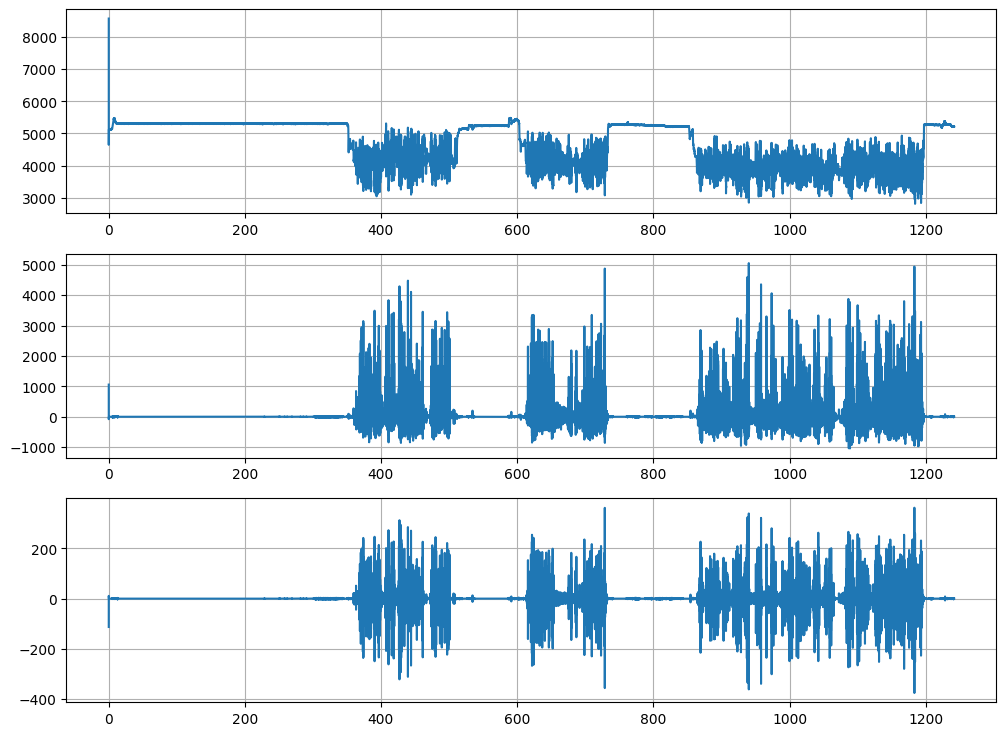

In [ ]:
#mag_zv_points = ws["mag_zv_points"]

local_max_indices = (np.diff(np.sign(np.diff(b_proj))) < 0).nonzero()[0] + 1
local_min_indices = (np.diff(np.sign(np.diff(b_proj))) > 0).nonzero()[0] + 1
mag_zv_points = np.sort(np.concatenate((local_max_indices, local_min_indices)))
print("Mean V at ZV:", np.mean(np.abs(v_gt[mag_zv_points])))
plt.figure(figsize=(12, 9))
plt.subplot(3, 1, 1)
mag_zv_points_roi = (mag_zv_points > roi.start) & (mag_zv_points < roi.stop)
mag_zv_points_roi = mag_zv_points[mag_zv_points_roi] - roi.start
plt.plot(t[roi], b_proj[roi])
plt.scatter(t[roi][mag_zv_points_roi], b_proj[roi][mag_zv_points_roi], color="red")
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], v_gt[roi])
plt.scatter(t[roi][mag_zv_points_roi], v_gt[roi][mag_zv_points_roi], color="red")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], a_gt[roi])
plt.scatter(t[roi][mag_zv_points_roi], a_gt[roi][mag_zv_points_roi], color="red")
plt.grid()

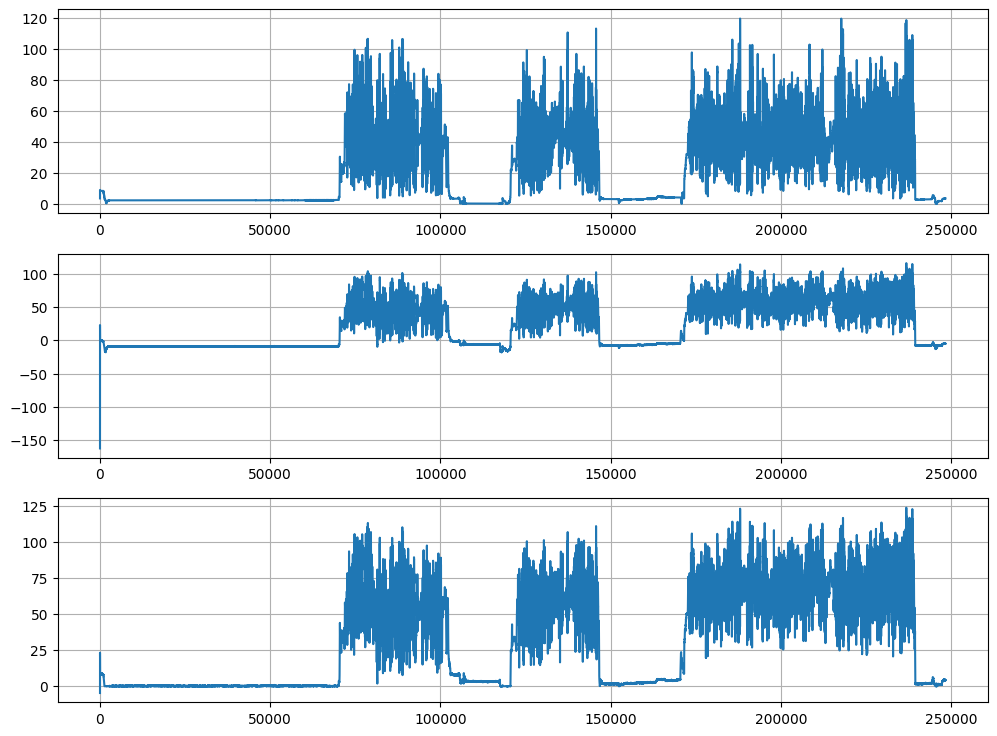

In [ ]:
# Plot pipeline outputs
travel_mag_adj = ws["travel/mag_model/adj__x"][:, 0]
travel_solved = ws["travel/solved__x"][:, 0]
travel_mag_adj -= np.mean(travel_mag_adj - travel)
#travel_solved -= np.mean(travel_solved - travel)

plt.figure(figsize=(12, 9))
plt.subplot(3, 1, 1)
plt.plot(travel[roi])
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(travel_mag_adj[roi])
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(travel_solved[roi])
plt.grid()

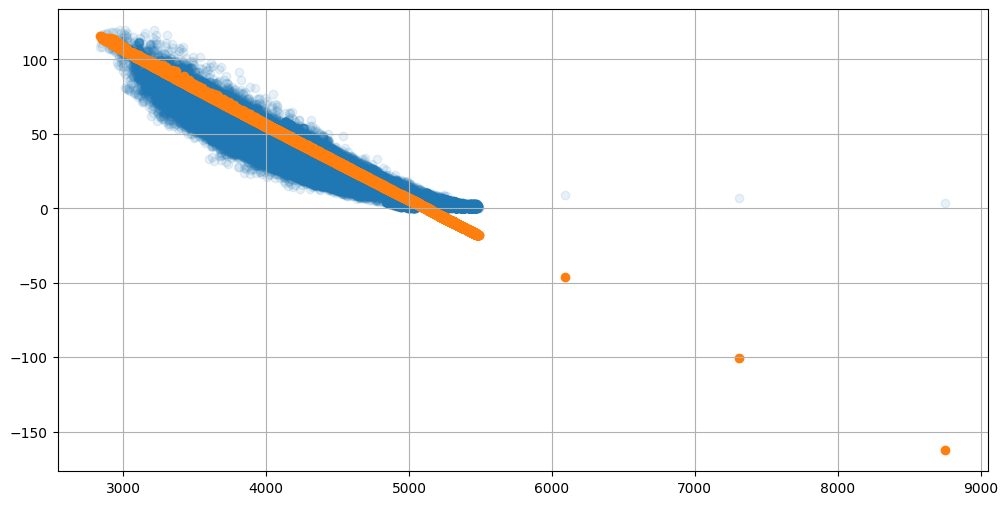

In [ ]:
# Scatter mag model errors
plt.figure(figsize=(12, 6))
plt.scatter(b_corr_mag, travel, alpha=0.1)
plt.scatter(b_corr_mag, travel_mag_adj)
#plt.scatter(b_corr_mag, travel_solved)
plt.grid()